# NER bi-LSTM

## Koneksi ke drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Install Requirement

In [2]:
from __future__ import absolute_import, division, print_function, unicode_literals
# Installing extra-dependencies
! pip -q install git+https://www.github.com/keras-team/keras-contrib.git sklearn-crfsuite

# try:
#   # The %tensorflow_version magic only works in colab.
#   %tensorflow_version 2.x
# except Exception:
#   pass

import tensorflow as tf
import keras

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 8.0 MB/s eta 0:00:00


In [3]:
print(tf.__version__)

2.15.0


## Set Paramater

In [4]:
BATCH_SIZE = 128  # Number of examples used in each iteration
EPOCHS = 50  # Number of passes through entire dataset
MAX_LEN = 10  # Max length of review (in words)
EMBEDDING = 100  # Dimension of word embedding vector

## Load Dataset

### Dataset Merge

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("ggplot")

dataset_path = "/content/drive/MyDrive/NER nlp/Dataset"
# /content/drive/MyDrive/NER nlp/bi-LSTM/LEGALNER-POS-PREV-NEXT-200.csv

data = pd.read_csv(dataset_path+"/Dataset-Merge.csv", encoding="latin1")

data['word'] = data['word'].str.lower()
data['word'] = data['word'].replace(to_replace ='\d+', value = '<\g<0>>', regex = True).replace(to_replace ='[0-9]', value = 'X', regex = True)
data = data.fillna(method="ffill")

In [6]:
data

,doc,sentence,word,prev,next,tag
0,doc: 1,sentence: 000001,putusan,.,nomor,O
1,doc: 1,sentence: 000001,nomor,putusan,325,O
2,doc: 1,sentence: 000001,<XXX>,nomor,/,B_VERN
3,doc: 1,sentence: 000001,/,325,pid,I_VERN
4,doc: 1,sentence: 000001,pid,/,.,I_VERN
...,...,...,...,...,...,...
7662673,doc: 1100,sentence: 140394,penuntut,.,umum,O
7662674,doc: 1100,sentence: 140394,umum,penuntut,dan,O
7662675,doc: 1100,sentence: 140394,dan,umum,terdakwa,O
7662676,doc: 1100,sentence: 140394,terdakwa,dan,.,O


In [7]:
data.groupby('tag').count()

,doc,sentence,word,prev,next
tag,,,,,
B_ADVO,3486,3486,3486,3486,3486
B_ARTV,2156,2156,2156,2156,2156
B_CRIA,205,205,205,205,205
B_DEFN,37722,37722,37722,37722,37722
B_JUDG,39,39,39,39,39
B_JUDP,10,10,10,10,10
B_PENA,1927,1927,1927,1927,1927
B_PROS,10,10,10,10,10
B_PUNI,92,92,92,92,92


### Menghilangkan kalimat yang hanya berisi O saja

In [8]:
data['tag'] = data['tag'].apply(lambda x: [x])
# Gabungkan tags dalam sentence yang sama dan hapus sentence yang hanya berisi tag 'O'
df_combined = (
    data.groupby(['doc', 'sentence'])['tag']
    .agg(lambda x: sum(x, []))
    .apply(lambda tags: tags if any(tag != 'O' for tag in tags) else [])
    .reset_index(name='tag')
)

# Hapus baris yang tidak memiliki tag atau memiliki tag kosong
df_combined = df_combined[df_combined['tag'].apply(lambda x: bool(x))]

# Buat DataFrame baru hanya berisi baris yang sesuai dengan df_combined
filtered_df = data[data['sentence'].isin(df_combined['sentence'])]

# Pisahkan df_combined per tag dan isi sentence berdasarkan tag yang dipisah tadi
result_rows = []
for index, row in filtered_df.iterrows():
    for tag in row['tag']:
        result_rows.append({
            'doc': row['doc'],
            'sentence': row['sentence'],
            'word': row['word'],
            # 'pos': row['pos'],
            'prev': row['prev'],
            'next': row['next'],
            'tag': tag
        })

# Tampilkan dataframe setelah penggabungan, penghapusan, pemisahan kembali tags, dan pengisian kolom 'sentence'
data = pd.DataFrame(result_rows)

# Tampilkan dataframe hasil
data

,doc,sentence,word,prev,next,tag
0,doc: 1,sentence: 000001,putusan,.,nomor,O
1,doc: 1,sentence: 000001,nomor,putusan,325,O
2,doc: 1,sentence: 000001,<XXX>,nomor,/,B_VERN
3,doc: 1,sentence: 000001,/,325,pid,I_VERN
4,doc: 1,sentence: 000001,pid,/,.,I_VERN
...,...,...,...,...,...,...
7627477,doc: 1100,sentence: 140394,penuntut,.,umum,O
7627478,doc: 1100,sentence: 140394,umum,penuntut,dan,O
7627479,doc: 1100,sentence: 140394,dan,umum,terdakwa,O
7627480,doc: 1100,sentence: 140394,terdakwa,dan,.,O


In [ ]:
data.groupby('tag').count()

,doc,sentence,word,prev,next
tag,,,,,
B_ADVO,3486,3486,3486,3486,3486
B_ARTV,2156,2156,2156,2156,2156
B_CRIA,205,205,205,205,205
B_DEFN,37722,37722,37722,37722,37722
B_JUDG,39,39,39,39,39
B_JUDP,10,10,10,10,10
B_PENA,1927,1927,1927,1927,1927
B_PROS,10,10,10,10,10
B_PUNI,92,92,92,92,92


In [ ]:
words = list(set(data["word"].values))
words.append("ENDPAD")
n_words = len(words); n_words

69608

In [ ]:
tags = list(set(data["tag"].values))
n_tags = len(tags); n_tags

25

### Mengelompokan berdasarkan Sentence dan Word

In [ ]:
class SentenceGetter(object):

    def __init__(self, data):
        self.n_sent = 1
        self.data = data
        self.empty = False
        agg_func = lambda s: [(w, t) for w, t in zip(s["word"].values.tolist(),
                                                           s["tag"].values.tolist())]
        self.grouped = self.data.groupby("sentence").apply(agg_func)
        self.sentences = [s for s in self.grouped]

    def get_next(self):
        try:
            s = self.grouped[self.n_sent]
            self.n_sent += 1
            return s
        except:
            return None

class DocGetter(object):

    def __init__(self, data):
        self.n_doc = 1
        self.data = data
        self.empty = False
        agg_func = lambda s: [(w, t) for w, t in zip(s["word"].values.tolist(),
                                                           s["tag"].values.tolist())]
        self.grouped = self.data.groupby("doc").apply(agg_func)
        self.docs = [s for s in self.grouped]

    def get_next(self):
        try:
            d = self.grouped[self.n_doc]
            self.n_doc += 1
            return d
        except:
            return None

In [ ]:
# getter = DocGetter(data)
# docs = getter.docs
getter = SentenceGetter(data)
sentences = getter.sentences

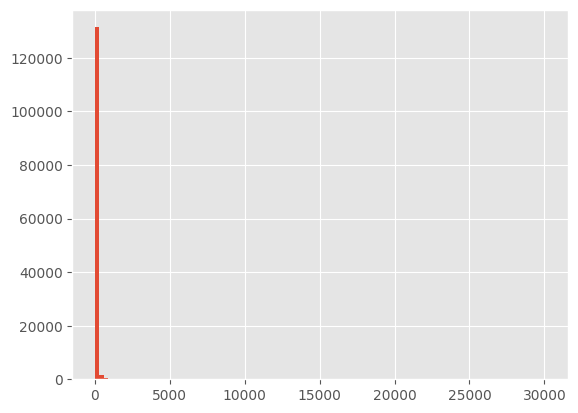

In [ ]:
import matplotlib.pyplot as plt
plt.style.use("ggplot")

plt.hist([len(s) for s in sentences], bins=100)
plt.show()

### Konversi tag ke numerik berdasarkan vocab

In [ ]:
# Vocabulary Key:word -> Value:token_index
# The first 2 entries are reserved for PAD and UNK
# word2idx = {w: i + 2 for i, w in enumerate(vocab)}
word2idx = {k: v + 2 for (k, v) in zip(words, range(len(words)))}
word2idx["UNK"] = 1 # Unknown words
word2idx["PAD"] = 0 # Padding

# Vocabulary Key:token_index -> Value:word
idx2word = {i: w for w, i in word2idx.items()}

# Vocabulary Key:Label/Tag -> Value:tag_index
# The first entry is reserved for PAD
tag2idx = {t: i+1 for i, t in enumerate(tags)}
tag2idx["PAD"] = 0

# Vocabulary Key:tag_index -> Value:Label/Tag
idx2tag = {i: w for w, i in tag2idx.items()}

### Split Data Training dan Testing

In [ ]:
from tensorflow.keras.utils import pad_sequences

# Convert each sentence from list of Token to list of word_index
X = [[word2idx[w[0]] for w in s] for s in sentences]
# Padding each sentence to have the same lenght
X = pad_sequences(maxlen=MAX_LEN, sequences=X, padding="post", value=word2idx["PAD"])


# Convert Tag/Label to tag_index
y = [[tag2idx[w[1]] for w in s] for s in sentences]
# Padding each sentence to have the same lenght
y = pad_sequences(maxlen=MAX_LEN, sequences=y, padding="post", value=tag2idx["PAD"])

from keras.utils import to_categorical
# One-Hot encode
y = [to_categorical(i, num_classes=n_tags+1) for i in y]

from sklearn.model_selection import train_test_split
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.1, shuffle=False)
X_tr.shape, X_te.shape, np.array(y_tr).shape, np.array(y_te).shape

((120727, 10), (13415, 10), (120727, 10, 26), (13415, 10, 26))

In [ ]:
print("The word indonesia is identified by the index: {}".format(word2idx["indonesia"]))
print("The labels B_ADVO is identified by the index: {}".format(tag2idx["B_ADVO"]))
i=2
print('Raw Sample  : ', ' '.join([w for w, t in getter.sentences[i]]))
print('Text2vec    : ', ' '.join(['{}'.format(word2idx[w]) for w, t in getter.sentences[i]]))
print('Text2vec PAD: ', ' '.join(['{}'.format(w) for w in X[i]]))
print('Raw Label   : ', ' '.join([t for w, t in getter.sentences[i]]))
print('Tag2vec     : ', ' '.join(['{}'.format(tag2idx[t]) for w, t in getter.sentences[i]]))

The word indonesia is identified by the index: 17100
The labels B_ADVO is identified by the index: 23
Raw Sample  :  umur / tanggal lahir : <XX> tahun / <X> maret <XXXX>
Text2vec    :  47692 34658 51097 47778 33365 47496 43061 34658 54696 26221 59142
Text2vec PAD:  34658 51097 47778 33365 47496 43061 34658 54696 26221 59142
Raw Label   :  O O B_VERN I_VERN I_VERN I_VERN I_VERN I_VERN I_VERN I_VERN I_VERN
Tag2vec     :  6 6 14 7 7 7 7 7 7 7 7


## Modeling bi-LSTM

In [ ]:
! pip install tensorflow-addons

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 611.8/611.8 kB 3.7 MB/s eta 0:00:00


### Arsitektur Model

In [ ]:
from keras import Model
from keras import optimizers
from keras.layers import Input, LSTM, Embedding, Dense, TimeDistributed, Dropout, Bidirectional, SpatialDropout1D
from tensorflow_addons.layers import CRF

input = Input(shape=(MAX_LEN,))

model = Embedding(input_dim=n_words, output_dim=EMBEDDING, input_length=MAX_LEN)(input)
model = Dropout(0.1)(model)
model = Bidirectional(LSTM(units=100, return_sequences=True, recurrent_dropout=0.1))(model)

out = TimeDistributed(Dense(n_tags+1, activation="softmax"))(model)  # softmax output layer

model = Model(input, out)

model.compile(optimizer="rmsprop", loss="categorical_crossentropy", metrics=["accuracy"])

model.summary()

### Training Model

In [ ]:
history = model.fit(np.array(X_tr).astype(int),
                    np.array(y_tr).astype(int),
                    batch_size=BATCH_SIZE,
                    epochs=EPOCHS,
                    validation_split=0.1,
                    verbose=1)

### Graph Training Model

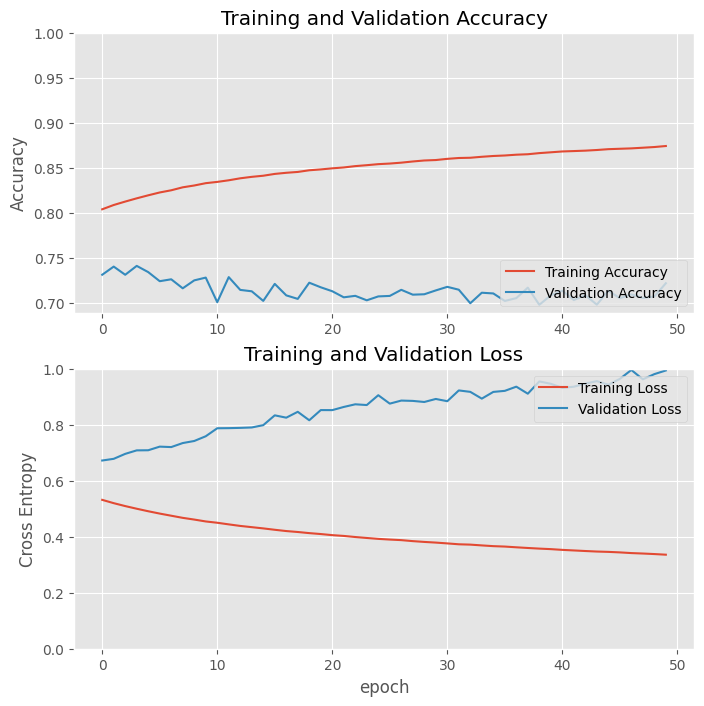

In [25]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.ylim([0,1.0])
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

### Save Model

In [ ]:
# !pip install pyyaml h5py  # Required to save models in HDF5 format

In [ ]:
# model.save('model-BiLSTM.h5')

In [ ]:
import torch

In [ ]:
path = 'model-BiLSTM.pth'
torch.save(model, path)

## Evaluasi

In [26]:
# Evaluation
eve = model.predict(X_te)

420/420 [==============================] - 6s 13ms/step


In [27]:
y_pred = np.argmax(eve, axis=-1)
y_test_true = np.argmax(y_te, -1)

# Convert the index to tag
y_pred = [[idx2tag[i] for i in row] for row in y_pred]
y_test_true = [[idx2tag[i] for i in row] for row in y_test_true]

### Nilai Precision,Recall dan F-1 score

In [ ]:
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix

m = MultiLabelBinarizer().fit(y_test_true)
print("Precision Score: {}".format(precision_score(m.transform(y_test_true), m.transform(y_pred), average="macro")))
print("Recall Score   : {}".format(recall_score(m.transform(y_test_true), m.transform(y_pred), average="macro")))
print("F1-score Score : {}".format(f1_score(m.transform(y_test_true), m.transform(y_pred), average="macro")))

### Matriks Evaluasi

In [29]:
from sklearn.metrics import classification_report
def c_report(y_pred, y_true):
  # Menggabungkan elemen-elemen array menjadi satu list
  y_pred_flat = [item for sublist in y_pred for item in sublist]
  y_true_flat = [item for sublist in y_true for item in sublist]
  report = classification_report(y_pred_flat, y_true_flat)
  return report

In [ ]:
report = c_report(y_pred, y_test_true)
print(report)

## Catatan
- batch size kecilin
- bagaimana cara agar o tidak mendominasi pada matriks